> [!WARNING]
> This notebook is a historical report from baseline v1.
>
> Do not execute `Run All`.
>
> This notebook contains old validation logic generated through physical
> file relocation, old paths, and training commands. It is saved without
> changes to ensure reproducibility of the experiment history.
>
> To safely demonstrate the finished model, use:
> `notebooks/baseline_v1_single_image_eval.ipynb`.

In [4]:
import os
import shutil
import random
import yaml
import json
from pathlib import Path
from datetime import datetime

import torch
from ultralytics import RTDETR

from collections import Counter

import random
from IPython.display import Image as IPImage

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


This one is simple scripts to prepare train/val

In [ ]:
random.seed(42)

DATA_DIR = Path("data")
IMG_TRAIN = DATA_DIR / "images" / "train"
IMG_VAL   = DATA_DIR / "images" / "val"
LBL_TRAIN = DATA_DIR / "labels" / "train"
LBL_VAL   = DATA_DIR / "labels" / "val"

IMG_VAL.mkdir(parents=True, exist_ok=True)
LBL_VAL.mkdir(parents=True, exist_ok=True)

all_images = list(IMG_TRAIN.glob("*.jpg"))
random.shuffle(all_images)

val_size = int(len(all_images) * 0.2)
val_images = all_images[:val_size]

for img_path in val_images:
    lbl_path = LBL_TRAIN / (img_path.stem + ".txt")
    shutil.move(str(img_path), IMG_VAL / img_path.name)
    if lbl_path.exists():
        shutil.move(str(lbl_path), LBL_VAL / lbl_path.name)

print(f"Train: {len(list(IMG_TRAIN.glob('*.jpg')))} images")
print(f"Val:   {len(list(IMG_VAL.glob('*.jpg')))} images")

Train: 2868 images
Val:   1613 images


In [9]:
CLASS_NAMES = {
    0: "HM", 1: "LQS", 2: "QHS", 3: "MS",
    4: "SU-35", 5: "C-130", 6: "C-17", 7: "C-5",
    8: "F-16", 9: "TU-160", 10: "E-3", 11: "B-52",
    12: "P-3C", 13: "B-1B", 14: "E-8", 15: "TU-22",
    16: "F-15", 17: "KC-135", 18: "F-22", 19: "FA-18",
    20: "TU-95", 21: "KC-10", 22: "SU-34", 23: "SU-24",
    24: "FSC"
}

counter = Counter()
for lbl in LBL_TRAIN.glob("*.txt"):
    for line in lbl.read_text().strip().splitlines():
        if line:
            cls = int(line.split()[0])
            counter[cls] += 1

print(f"{'ID':<4} {'Name':<12} {'Count':>8}")
print("-" * 28)
for cls_id in sorted(counter):
    print(f"{cls_id:<4} {CLASS_NAMES[cls_id]:<12} {counter[cls_id]:>8}")
print(f"\nTotal objects: {sum(counter.values())}")
print(f"Rarest class:  {CLASS_NAMES[counter.most_common()[-1][0]]} = {counter.most_common()[-1][1]}")

ID   Name            Count
----------------------------
0    HM                  4
1    LQS                19
2    QHS               389
3    MS               1280
4    SU-35             821
5    C-130             702
6    C-17              608
7    C-5               308
8    F-16              623
9    TU-160            236
10   E-3               373
11   B-52              506
12   P-3C              573
13   B-1B              519
14   E-8               317
15   TU-22             372
16   F-15              772
17   KC-135            869
18   F-22              336
19   FA-18            1480
20   TU-95             730
21   KC-10             201
22   SU-34             629
23   SU-24             460
24   FSC               277

Total objects: 13404
Rarest class:  HM = 4


In [14]:
WEIGHTS = Path("models/rtdetr-l.pt")
WEIGHTS.parent.mkdir(exist_ok=True)

if not WEIGHTS.exists():
    import urllib.request
    urllib.request.urlretrieve(
        "https://github.com/ultralytics/assets/releases/download/v8.3.0/rtdetr-l.pt",
        WEIGHTS
    )

model = RTDETR(str(WEIGHTS))

results = model.train(
    data="data/dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0,
    fraction=0.5,
    optimizer="AdamW",
    lr0=1e-4,
    weight_decay=1e-4,
    warmup_epochs=3,
    fliplr=0.5,
    flipud=0.2,
    degrees=15.0,
    patience=10,
    project="runs/detect/results",
    name="baseline_full",
    save_period=10,
    val=True
)

Ultralytics 8.4.114 🚀 Python-3.13.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/dataset.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=0.5, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline

/home/irdorat/miniconda3/envs/ML_comp/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      8.01G     0.8725      1.628     0.4319         47        640: 100% ━━━━━━━━━━━━ 224/224 9.3s/it 34:549.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 2.6it/s 21.2s0.3ss
                   all        896       4294    0.00203      0.037   0.000739   0.000272

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/home/irdorat/miniconda3/envs/ML_comp/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      6.91G     0.5851      1.789     0.2482         53        640: 100% ━━━━━━━━━━━━ 224/224 4.9s/it 18:254.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 3.1it/s 18.1s0.3s
                   all        896       4294     0.0013     0.0806    0.00171   0.000966

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

/home/irdorat/miniconda3/envs/ML_comp/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      25/50      6.86G     0.4114     0.5973     0.1745         35        640: 100% ━━━━━━━━━━━━ 224/224 6.8s/it 25:246.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 3.6it/s 15.8s0.3s
                   all        896       4294      0.742      0.675      0.689      0.344

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/home/irdorat/miniconda3/envs/ML_comp/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      26/50      6.89G     0.3475     0.5806      0.135         32        640: 1% ──────────── 3/224 10.1s/it 26.9s<37:1627


KeyboardInterrupt: 

In [16]:
CHECKPOINT = "runs/detect/results/baseline_full/weights/last.pt"

model = RTDETR(CHECKPOINT)

model.train(resume=True)

New https://pypi.org/project/ultralytics/8.4.115 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.114 🚀 Python-3.13.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/dataset.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=0.5, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup

/home/irdorat/miniconda3/envs/ML_comp/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      26/50      7.06G     0.4065     0.5976     0.1732         47        640: 100% ━━━━━━━━━━━━ 224/224 7.0s/it 26:106.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 2.4it/s 23.3s0.4ss
                   all        896       4294      0.743      0.692      0.701       0.34

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/home/irdorat/miniconda3/envs/ML_comp/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      27/50      6.79G     0.4102     0.5816     0.1746         53        640: 100% ━━━━━━━━━━━━ 224/224 6.1s/it 22:375.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 2.9it/s 19.5s0.3s
                   all        896       4294      0.781      0.682      0.722      0.329

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

/home/irdorat/miniconda3/envs/ML_comp/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50       6.9G     0.3304     0.4531     0.1629         28        640: 100% ━━━━━━━━━━━━ 224/224 7.1s/it 26:297.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 2.4it/s 23.0s0.4ss
                   all        896       4294      0.772      0.792      0.804      0.431

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/home/irdorat/miniconda3/envs/ML_comp/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      6.81G      0.335     0.4476     0.1641         23        640: 100% ━━━━━━━━━━━━ 224/224 5.9s/it 22:025.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 3.1it/s 18.0s0.3s
                   all        896       4294      0.782      0.793      0.806      0.443

25 epochs completed in 14.150 hours.
Optimizer stripped from /home/irdorat/ML_comp/runs/detect/runs/detect/results/baseline_full/weights/last.pt, 66.3MB
Optimizer stripped from /home/irdorat/ML_comp/runs/detect/runs/detect/results/baseline_full/weights/best.pt, 66.3MB

Validating /home/irdorat/ML_comp/runs/detect/runs/detect/results/baseline_full/weights/best.pt...
Ultralytics 8.4.114 🚀 Python-3.13.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
rt-detr-l summary: 315 layers, 32,035,115 parameters, 0 gradients, 105.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a6ee7e47a10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,  

In [5]:
CHECKPOINT = "runs/detect/results/baseline_full/weights/best.pt"

model = RTDETR(CHECKPOINT)

In [10]:
metrics = model.val(data="data/dataset.yaml", split="val")

print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Recall:   {metrics.box.r.mean():.4f}")
print(f"Precision:{metrics.box.p.mean():.4f}")

# метрики по классам
print("\nПо классам:")
for i, name in CLASS_NAMES.items():
    if i < len(metrics.box.ap):
        print(f"  {name:<12} AP50={metrics.box.ap50[i]:.3f}")

Ultralytics 8.4.114 🚀 Python-3.13.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
rt-detr-l summary: 315 layers, 32,035,115 parameters, 0 gradients, 105.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 955.5±1046.5 MB/s, size: 322.2 KB)
val: Scanning /home/irdorat/ML_comp/data/labels/val... 1613 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1613/1613 877.3it/s 1.8s0.0s
val: /home/irdorat/ML_comp/data/images/val/fsc_TG-N22.33-E120.62-lv20-Google_crop0002.jpg: 1 duplicate labels removed
val: New cache created: /home/irdorat/ML_comp/data/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 2.3it/s 43.2s0.4s
                   all       1613       7528      0.849      0.761      0.808      0.453
                    HM         11         13          1          0     0.0307     0.0163
                   LQS          9         11          1          0     0.0466       0.0

In [12]:
out_dir = Path("runs/detect/results/baseline_full")

config = {
    "run_id": "baseline_v1",
    "date": datetime.now().isoformat(),
    "model": "RT-DETR-L",
    "pretrained": "COCO",
    "epochs": 50,
    "imgsz": 640,         
    "batch": 8,
    "optimizer": "AdamW",
    "lr0": 1e-4,
    "weight_decay": 1e-4,
    "fraction": 0.5,
    "metrics": {
        "precision": float(metrics.box.p.mean()),
        "recall": float(metrics.box.r.mean()),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map),
    },
}

with open(out_dir / "config.json", "w") as f:
    json.dump(config, f, indent=4)

print("Сохранено:", out_dir / "config.json")
print("Лучшие веса:", out_dir / "weights" / "best.pt")

Сохранено: runs/detect/results/baseline_full/config.json
Лучшие веса: runs/detect/results/baseline_full/weights/best.pt



image 1/1 /home/irdorat/ML_comp/data/images/val/MAR20_1648.jpg: 640x640 7 A1_SU-35s, 5 A19_SU-34s, 40.3ms
Speed: 6.0ms preprocess, 40.3ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /home/irdorat/ML_comp/runs/detect/runs/detect/results/preview


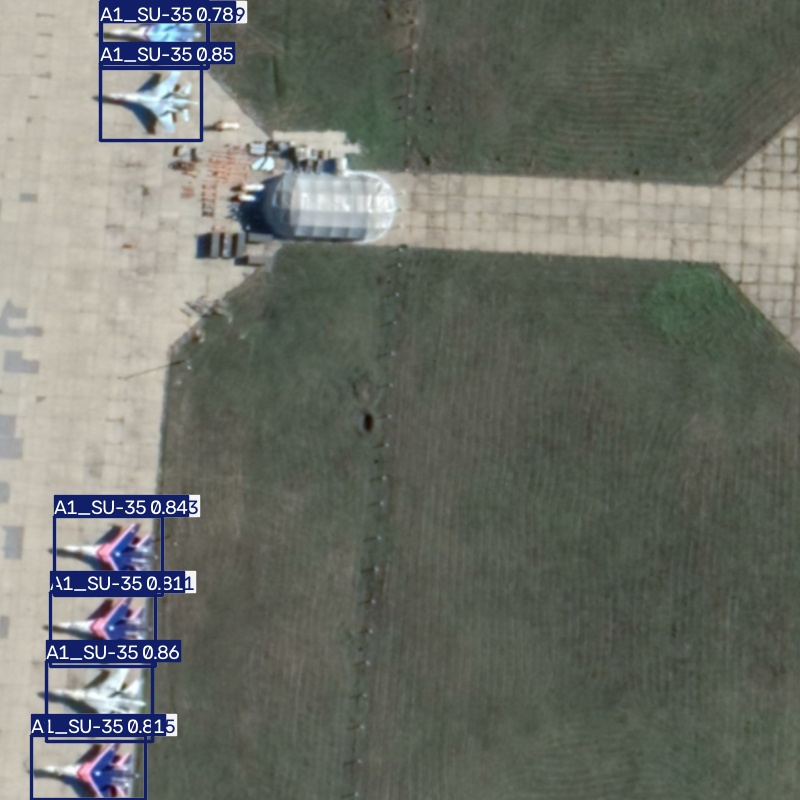

In [13]:
val_imgs = list((Path("data/images/val")).glob("*.jpg"))
sample = random.choice(val_imgs)

model = RTDETR(str(Path("runs/detect/results/baseline_full/weights/best.pt")))

result = model.predict(
    str(sample),
    conf=0.3,
    save=True,
    project="runs/detect/results",
    name="preview"
)

saved = Path(result[0].save_dir) / sample.name
IPImage(str(saved))

## Summary

Baseline v1 is complete and saved as a project checkpoint.

Saved aggregated results:

- Precision: 0.849;
- Recall: 0.761;
- mAP50: 0.808;
- mAP50–95: 0.453.